# Notebook 3: Exploratory Data Analysis

## Objective

The purpose of this notebook is to explore historical stock market data for five major technology companies (Apple, Microsoft, NVIDIA, Amazon, and Google). Through exploratory data analysis, we aim to identify patterns in stock performance, compare companies using financial metrics, and generate insights that will inform the development of an interactive Tableau dashboard.

### Business Question

**What factors explain stock performance, and how can investors compare companies efficiently?**

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
df = pd.read_csv("../data/processed/master_stock_data.csv")

df["Date"] = pd.to_datetime(df["Date"])

# Analysis 1: Which stock performed the best?

### Business Question

Which company generated the highest overall return between 2020 and 2025?

Understanding cumulative stock returns helps investors identify which companies delivered the strongest long-term capital appreciation.

In [27]:
performance = []

for ticker in df["Ticker"].unique():

    stock = df[df["Ticker"] == ticker]

    start_price = stock.iloc[0]["Adj Close"]
    end_price = stock.iloc[-1]["Adj Close"]

    total_return = ((end_price - start_price) / start_price) * 100

    performance.append({
        "Ticker": ticker,
        "Return (%)": total_return
    })

performance_df = pd.DataFrame(performance)

performance_df

,Ticker,Return (%)
0,AAPL,244.002318
1,MSFT,174.359286
2,NVDA,2148.392944
3,AMZN,131.178977
4,GOOGL,177.619681


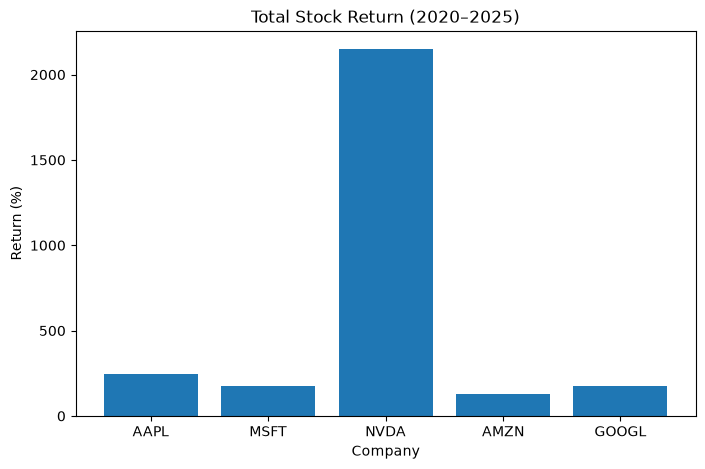

In [28]:
plt.figure(figsize=(8,5))

plt.bar(
    performance_df["Ticker"],
    performance_df["Return (%)"]
)

plt.title("Total Stock Return (2020–2025)")
plt.xlabel("Company")
plt.ylabel("Return (%)")

plt.show()

## Interpretation

NVIDIA delivered by far the strongest stock performance over the five-year period, generating a cumulative return of over 2,000%, significantly outperforming the other four companies.

Apple, Microsoft, Amazon and Google all produced positive long-term returns, but their gains were considerably smaller, ranging between approximately 130% and 250%.

This indicates that investors who held NVIDIA throughout the period would have achieved substantially higher capital appreciation than investors in the other companies.

## Key Insight

NVIDIA was the clear market leader in terms of long-term returns during 2020–2025, highlighting its exceptional growth over the period.

# Analysis 2: Which stock is the most volatile?

### Business Question

Which company exhibits the greatest price volatility?

Volatility measures how much a stock's price fluctuates over time. Higher volatility generally indicates higher investment risk.

In [29]:
risk = df.groupby("Ticker")["Adj Close"].std().reset_index()

risk.columns = ["Ticker","Volatility"]

risk

,Ticker,Volatility
0,AAPL,41.851998
1,AMZN,32.004698
2,GOOGL,32.234703
3,MSFT,81.058643
4,NVDA,38.176863


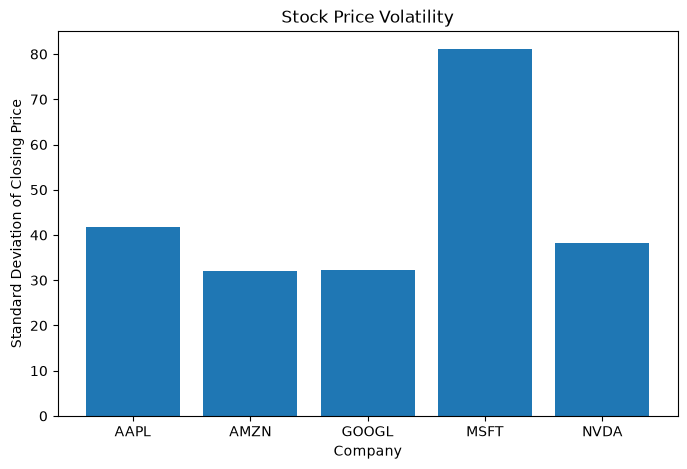

In [30]:
plt.figure(figsize=(8,5))

plt.bar(
    risk["Ticker"],
    risk["Volatility"]
)

plt.title("Stock Price Volatility")
plt.xlabel("Company")
plt.ylabel("Standard Deviation of Closing Price")

plt.show()

## Interpretation

Microsoft recorded the highest standard deviation of closing prices, suggesting that its stock price experienced the largest absolute price fluctuations throughout the period.

Amazon and Google exhibited the lowest price volatility among the five companies, while Apple and NVIDIA showed moderate levels of variation.

Although high volatility often implies greater investment risk, it can also reflect stronger price momentum and larger potential returns.

## Key Insight

Microsoft experienced the greatest price fluctuations, whereas Amazon and Google displayed relatively more stable price movements over the analysis period.

# Analysis 3: Which company has the highest average trading volume?

### Business Question

Which company's shares are traded most frequently?

Trading volume provides insight into market liquidity and investor interest.

In [31]:
volume = (
    df.groupby("Ticker")["Volume"]
      .mean()
      .reset_index()
)

volume

,Ticker,Volume
0,AAPL,9.057103e+07
1,AMZN,6.848852e+07
2,GOOGL,3.308850e+07
3,MSFT,2.863777e+07
4,NVDA,4.467728e+08


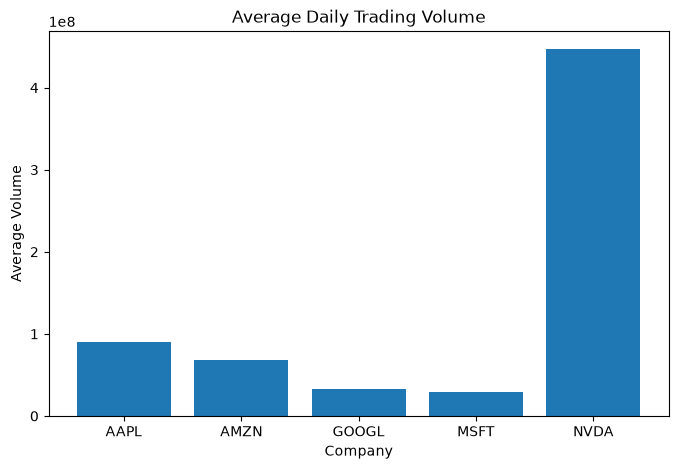

In [32]:
plt.figure(figsize=(8,5))

plt.bar(
    volume["Ticker"],
    volume["Volume"]
)

plt.title("Average Daily Trading Volume")
plt.xlabel("Company")
plt.ylabel("Average Volume")

plt.show()

## Interpretation

NVIDIA recorded the highest average daily trading volume by a substantial margin, indicating significantly greater investor participation compared with the other companies.

Apple ranked second in trading activity, while Microsoft and Google showed comparatively lower average trading volumes.

High trading volume generally reflects strong market interest and provides greater liquidity, making it easier for investors to buy and sell shares without substantially affecting market prices.

## Key Insight

NVIDIA attracted the highest level of investor trading activity, suggesting strong market interest and excellent liquidity throughout the period.

# Analysis 4: How are closing prices distributed?

### Business Question

How does the distribution of stock prices differ across companies?

A box plot allows us to compare the spread, median, and variability of stock prices between companies.

<Figure size 1000x600 with 0 Axes>

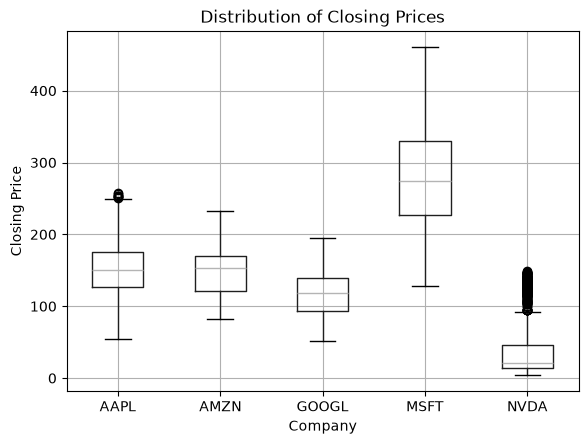

In [33]:
plt.figure(figsize=(10,6))

df.boxplot(
    column="Adj Close",
    by="Ticker"
)

plt.title("Distribution of Closing Prices")
plt.suptitle("")

plt.xlabel("Company")
plt.ylabel("Closing Price")

plt.show()

## Interpretation

The box plot shows clear differences in the range and spread of stock prices across the five companies.

Microsoft maintained the highest overall price levels throughout the period, with a wide distribution that reflects substantial changes over time.

NVIDIA exhibited numerous upper outliers, indicating periods of exceptionally rapid price appreciation compared with its historical range.

Apple, Amazon and Google displayed comparatively narrower distributions, suggesting more consistent pricing during the observation period.

## Key Insight

Microsoft consistently traded at the highest price levels, while NVIDIA exhibited the strongest upward price movements, reflected by numerous high-value outliers.

# Analysis 5: How closely do these stocks move together?

### Business Question

Do the five technology stocks tend to move in the same direction?

Correlation analysis helps investors understand diversification opportunities and relationships between stocks.

In [34]:
pivot = df.pivot(
    index="Date",
    columns="Ticker",
    values="Adj Close"
)

pivot.head()

Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2020-01-02,72.333878,94.900497,67.832497,151.829529,5.963803
2020-01-03,71.630661,93.748497,67.477661,149.938995,5.868347
2020-01-06,72.201416,95.143997,69.276207,150.326523,5.892956
2020-01-07,71.861855,95.343002,69.142395,148.955963,5.964300
2020-01-08,73.017845,94.598503,69.634537,151.328583,5.975486


In [35]:
corr = pivot.corr()

corr

Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
Ticker,,,,,
AAPL,1.000000,0.521433,0.894021,0.930175,0.824411
AMZN,0.521433,1.000000,0.692026,0.614097,0.623923
GOOGL,0.894021,0.692026,1.000000,0.938463,0.816305
MSFT,0.930175,0.614097,0.938463,1.000000,0.892032
NVDA,0.824411,0.623923,0.816305,0.892032,1.000000


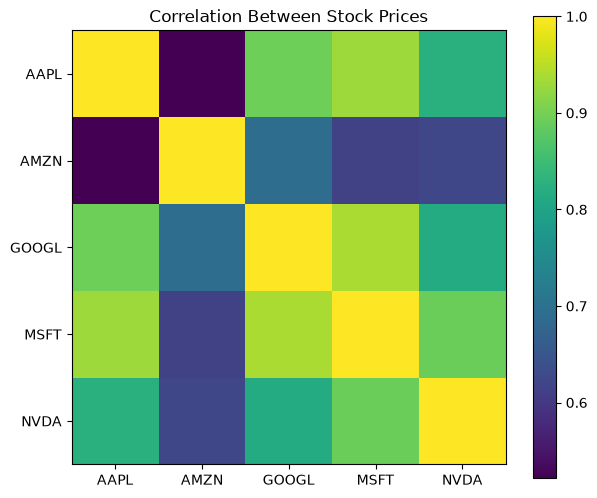

In [36]:
plt.figure(figsize=(7,6))

plt.imshow(corr)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Between Stock Prices")

plt.show()

## Interpretation

Most of the technology stocks demonstrate strong positive correlations, indicating that their prices generally moved in the same direction over time.

Apple, Microsoft and Google show particularly strong relationships, suggesting they were influenced by similar market conditions and sector-wide trends.

Amazon displays weaker correlations with the remaining companies, implying that its stock performance was somewhat more independent.

Overall, the heatmap suggests that although all companies belong to the technology sector, their degree of co-movement varies.

## Key Insight

Apple, Microsoft and Google exhibited the strongest co-movement, while Amazon behaved more independently relative to the other technology stocks.

## Overall Findings

The exploratory analysis reveals that the five technology companies displayed distinct investment characteristics between 2020 and 2025.

- NVIDIA achieved the strongest overall return and attracted the highest trading volume, reflecting exceptional investor interest and growth.

- Microsoft exhibited the greatest price volatility and maintained the highest average price levels.

- Apple, Microsoft and Google showed strong positive correlations, indicating similar market behaviour.

- Amazon displayed comparatively lower volatility and weaker correlations with the other companies, suggesting slightly different price dynamics.

These findings establish a strong foundation for the next stage of the project, where financial ratios and company fundamentals will be incorporated to better explain why certain companies outperformed others.